In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(175.5), np.float64(285.5), np.float64(-0.5))

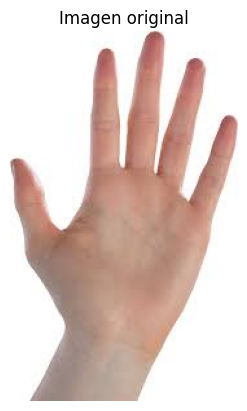

In [10]:
imagen = cv2.imread("img/mano.jpeg")

plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen original")
plt.axis("off")

(np.float64(-0.5), np.float64(175.5), np.float64(285.5), np.float64(-0.5))

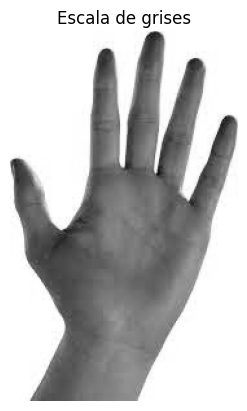

In [11]:
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.imshow(gris, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

(np.float64(-0.5), np.float64(175.5), np.float64(285.5), np.float64(-0.5))

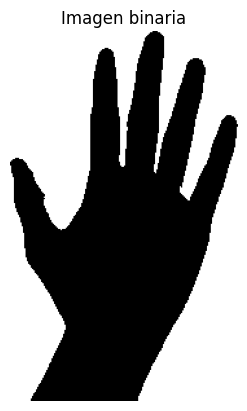

In [22]:
_, binaria = cv2.threshold(
    gris,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(binaria, cmap="gray")
plt.title("Imagen binaria")
plt.axis("off")

(np.float64(-0.5), np.float64(175.5), np.float64(285.5), np.float64(-0.5))

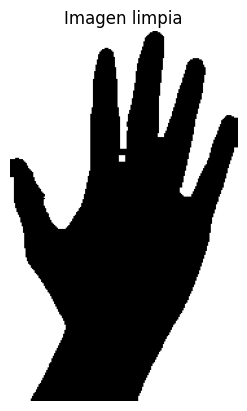

In [32]:
kernel = np.ones((1,3), np.uint8)

binaria_limpia = cv2.morphologyEx(
    binaria,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

plt.imshow(binaria_limpia, cmap="gray")
plt.title("Imagen limpia")
plt.axis("off")

In [33]:
size = np.size(binaria_limpia)
skeleton = np.zeros(binaria_limpia.shape, np.uint8)

element = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))

done = False

img = binaria_limpia.copy()

while not done:
    
    eroded = cv2.erode(img, element)
    temp = cv2.dilate(eroded, element)
    temp = cv2.subtract(img, temp)
    skeleton = cv2.bitwise_or(skeleton, temp)
    img = eroded.copy()

    zeros = size - cv2.countNonZero(img)
    
    if zeros == size:
        done = True

(np.float64(-0.5), np.float64(175.5), np.float64(285.5), np.float64(-0.5))

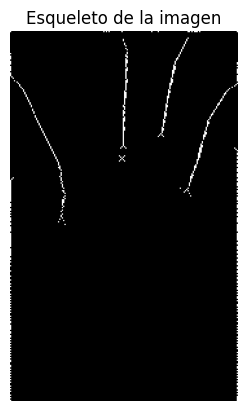

In [34]:
plt.imshow(skeleton, cmap="gray")
plt.title("Esqueleto de la imagen")
plt.axis("off")